# 📊 Stats Wales Data Explorer

Welcome to the Stats Wales workshop notebook! 🏴󠁧󠁢󠁷󠁬󠁳󠁿

This notebook is **ready to go** — just run each cell from top to bottom. The only thing you need to do is pick a dataset and paste its ID!

### What you'll do:
1. ✅ Load all the Python libraries (just run it)
2. 🔍 Browse the list of available Stats Wales datasets
3. ✏️ **Pick a dataset and paste its ID** into the code
4. 📊 Create a bar chart (customise the title & colours)
5. 💾 Export everything for your GitHub Pages dashboard

### Your focus:
- **Choose a dataset** that interests you
- **Customise** small bits marked with ✏️ (title, colours, etc.)
- **Commit your changes** using Git — that's the real skill here!

---

**💡 Tip:** Use GitHub Copilot to help you! Press `Ctrl+I` (or `Cmd+I` on Mac) to open Copilot Chat. Try prompts like:
- *"Explain what this code does"*
- *"Help me change the chart colours"*

## Step 1 — Load Libraries

Run this cell first — it loads everything you need.
*(Everything is already installed in Codespaces — no setup required!)*

In [20]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from io import StringIO

print("✅ Libraries loaded successfully! Move on to Step 2.")

✅ Libraries loaded successfully! Move on to Step 2.


## Step 2 — Browse Available Datasets

Run this cell to see what datasets are available on Stats Wales. Scroll through the list and **find one that interests you** — you'll need its `id` in the next step.

> **💡 Tip:** Look for something relevant to your work — health, population, education, economics. You'll be more engaged if the data means something to you!

In [21]:
# ─── Browse all available Stats Wales datasets ────────────────────────
datasets_url = "https://api.stats.gov.wales/v1/?lang=en-gb&page_number=1&page_size=100"

response = requests.get(datasets_url)
response.raise_for_status()

datasets = response.json()
df_datasets = pd.DataFrame(datasets.get("value", datasets))
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

print(f"📋 Found {len(df_datasets)} datasets\n")
print("Scroll through the list below and pick one you like.")
print("Copy its 'id' value — you'll paste it in the next step!\n")

# Show the id and title so you can pick one
cols_to_show = [c for c in ["id", "title", "description"] if c in df_datasets.columns]
if cols_to_show:
    display(df_datasets[cols_to_show])
else:
    display(df_datasets)

📋 Found 100 datasets

Scroll through the list below and pick one you like.
Copy its 'id' value — you'll paste it in the next step!



,data,count
0,"{'id': '31064862-72d5-42cf-a029-6ee93a9cb86c', 'title': 'Adult community learning outcomes by ethnic background, gender, home region, age group, and year', 'first_published_at': '2026-03-18T09:30:00.000Z', 'last_updated_at': '2026-03-18T09:30:00.000Z', 'archived_at': None}",712
1,"{'id': 'd71e3dfe-dc62-4c4c-b735-2fdebb1e595e', 'title': 'Adult community learning outcomes by sector subject area, provision, level, age group, and year', 'first_published_at': '2026-03-18T09:30:00.000Z', 'last_updated_at': '2026-03-18T09:30:00.000Z', 'archived_at': None}",712
2,"{'id': '572def66-eb0d-4527-b29f-7b2f9c2f7c6a', 'title': 'Apprenticeship outcomes by sector, home region, programme, age group, gender, and year', 'first_published_at': '2026-03-18T09:30:00.000Z', 'last_updated_at': '2026-03-18T09:30:00.000Z', 'archived_at': None}",712
3,"{'id': '19b54b94-78c1-4b74-86d0-57ad74f1d994', 'title': 'Apprenticeship outcomes by learner demographics, home region, age group, gender, and year', 'first_published_at': '2026-03-18T09:30:00.000Z', 'last_updated_at': '2026-03-18T09:30:00.000Z', 'archived_at': None}",712
4,"{'id': 'dc5ab135-ec49-44b3-9c70-f8148a876818', 'title': 'Welsh language skill and ability of wider practice staff (headcount) by local health board', 'first_published_at': '2026-03-17T09:30:00.000Z', 'last_updated_at': '2026-03-17T09:30:00.000Z', 'archived_at': None}",712
5,"{'id': 'ec92c8ef-4e4e-453e-9ff6-2c8dd901a946', 'title': 'Wider practice staff (headcount and full-time equivalent) by sex and local health board', 'first_published_at': '2026-03-17T09:30:00.000Z', 'last_updated_at': '2026-03-17T09:30:00.000Z', 'archived_at': None}",712
6,"{'id': '1acd1008-46ce-4081-b8c3-db52fdcd5ebd', 'title': 'Fully qualified GPs (headcount and full-time equivalent) by ethnicity', 'first_published_at': '2026-03-17T09:30:00.000Z', 'last_updated_at': '2026-03-17T09:30:00.000Z', 'archived_at': None}",712
7,"{'id': 'aa0dfad5-1d5b-4ac3-bd3c-8920966b5348', 'title': 'Wider practice staff (headcount and full-time equivalent) by age band and local health board', 'first_published_at': '2026-03-17T09:30:00.000Z', 'last_updated_at': '2026-03-17T09:30:00.000Z', 'archived_at': None}",712
8,"{'id': '73c77570-4ac3-4b14-90ca-8bae3a577bab', 'title': 'Fully qualified GPs (headcount) by sex and full-time and part-time', 'first_published_at': '2026-03-17T09:30:00.000Z', 'last_updated_at': '2026-03-17T09:30:00.000Z', 'archived_at': None}",712
9,"{'id': 'f670ec3e-f46c-444e-816d-83da35ef2e43', 'title': 'Welsh language skill and ability of fully qualified GPs (headcount) by local health board', 'first_published_at': '2026-03-17T09:30:00.000Z', 'last_updated_at': '2026-03-17T09:30:00.000Z', 'archived_at': None}",712


## Step 3 — Fetch Your Chosen Dataset

Now paste the `id` you copied from Step 2 into the `DATASET_ID` line below, replacing the placeholder text. Then run the cell!

**How to do it:**
1. Find the `DATASET_ID = "PASTE_YOUR_DATASET_ID_HERE"` line below
2. Delete `PASTE_YOUR_DATASET_ID_HERE` and paste in the `id` you copied (keep the quotes!)
3. Run the cell with **Shift+Enter**

> **💡 Copilot tip:** If you get an error, ask Copilot: *"I'm getting this error: [paste error]. How do I fix it?"*

In [22]:
# ─── Fetch data from your chosen dataset ──────────────────────────────
# ✏️ PASTE YOUR DATASET ID BELOW (replace the placeholder text)
DATASET_ID = "61255cb5-5a39-4d1a-bcab-4d9628480aac"
# ──────────────────────────────────────────────────────────────────────

if DATASET_ID == "PASTE_YOUR_DATASET_ID_HERE":
    print("⚠️  You need to paste a Dataset ID first!")
    print("   Go back to Step 2, pick a dataset, and copy its 'id' value.")
    print("   Then replace PASTE_YOUR_DATASET_ID_HERE above (keep the quotes).")
else:
    # Fetch the data
    params = {
        "lang": "en-gb",
        "page_number": 1,
        "page_size": 100,
    }

    data_url = f"https://api.stats.gov.wales/v1/{DATASET_ID}/view"
    response = requests.get(data_url, params=params)
    response.raise_for_status()

    data = response.json()
    
    # Handle Stats Wales API response format (has 'data' and 'headers')
    if isinstance(data, dict):
        if "data" in data and "headers" in data:
            # Extract headers and data rows
            headers = [h.get("label", h.get("name", f"Column_{i}")) for i, h in enumerate(data.get("headers", []))]
            rows = data.get("data", [])
            df = pd.DataFrame(rows, columns=headers)
        elif "value" in data:
            # Fallback for other dict structures
            records = data.get("value", [])
            df = pd.DataFrame(records)
        else:
            # Last resort: treat as single record
            df = pd.DataFrame([data])
    else:
        # If it's already a list
        df = pd.DataFrame(data)
    
    # Fill missing values and clean up
    df = df.fillna("")
    
    print(f"✅ Loaded {len(df)} rows and {len(df.columns)} columns from Stats Wales")
    print(f"\nColumns: {list(df.columns)}\n")
    display(df.head(10))


✅ Loaded 100 rows and 4 columns from Stats Wales

Columns: ['Data values', 'Data description', 'Date', 'Area']



,Data values,Data description,Date,Area
0,3,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Wales
1,2,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Betsi Cadwaladr University Health Board
2,1,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Powys Teaching Health Board
3,1,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Hywel Dda University Health Board
4,5,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Swansea Bay University Health Board
5,5,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Cwm Taf Morgannwg University Health Board
6,2,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Aneurin Bevan University Health Board
7,4,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Cardiff and Vale University Health Board
8,2,"Welsh speaking dentists per 10,000 Welsh speaking people",22/08/2024,Wales
9,2,"Welsh speaking dentists per 10,000 Welsh speaking people",22/08/2024,Betsi Cadwaladr University Health Board


## Step 4 — Create Your Chart 📊

This cell creates a bar chart from the data. It automatically detects the right columns!

### ✏️ Things you can customise (try changing these!):
- **`CHART_TITLE`** — Give your chart a meaningful name
- **`BAR_COLOURS`** — Change the colours (use hex codes like `"#007C45"`)
- **`Y_LABEL`** — Change the Y-axis label

> **💡 Copilot tip:** Highlight the code and ask: *"Change this to a horizontal bar chart"* or *"Add data labels on each bar"*

In [23]:
# Quick check: What does the data actually look like?
print("Data types in each column:")
print(df.dtypes)
print("\n" + "="*50)
print("\nFirst few rows:")
display(df.head(3))
print("\n" + "="*50)
print("\nSample values from each column:")
for col in df.columns:
    print(f"\n{col}: {df[col].iloc[0]} (type: {type(df[col].iloc[0]).__name__})")


Data types in each column:
Data values         str
Data description    str
Date                str
Area                str
dtype: object


First few rows:


,Data values,Data description,Date,Area
0,3,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Wales
1,2,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Betsi Cadwaladr University Health Board
2,1,"Welsh speaking dentists per 10,000 Welsh speaking people",31/08/2025,Powys Teaching Health Board




Sample values from each column:

Data values:            3 (type: str)

Data description: Welsh speaking dentists per 10,000 Welsh speaking people (type: str)

Date: 31/08/2025 (type: str)

Area: Wales (type: str)


📊 Charting: Data values by Area

Preview of converted values:
                                        Area  Data values
0                                      Wales            3
1    Betsi Cadwaladr University Health Board            2
2                Powys Teaching Health Board            1
3          Hywel Dda University Health Board            1
4        Swansea Bay University Health Board            5
5  Cwm Taf Morgannwg University Health Board            5
6      Aneurin Bevan University Health Board            2
7   Cardiff and Vale University Health Board            4
8                                      Wales            2
9    Betsi Cadwaladr University Health Board            2

Data for chart:
Area
Wales                                        839
Betsi Cadwaladr University Health Board      275
Cwm Taf Morgannwg University Health Board    163
Cardiff and Vale University Health Board     133
Hywel Dda University Health Board            131
Swansea Bay University Health Boa

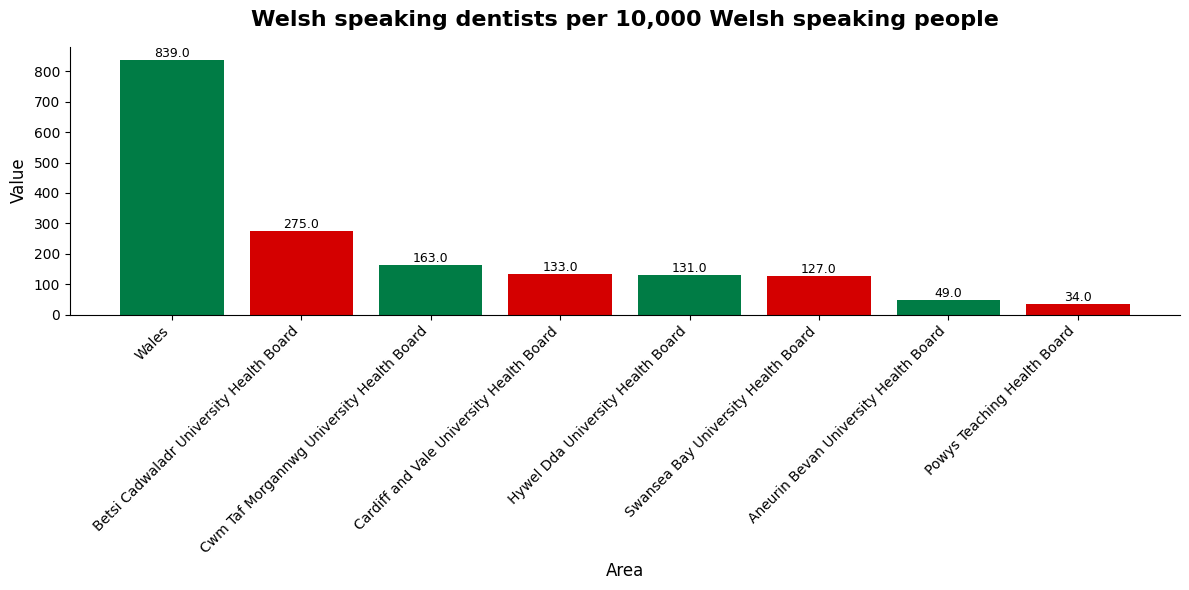

In [24]:
# ─── Create a chart ────────────────────────────────────────────────────
# ✏️ CUSTOMISE THESE — change the title, colours, or labels!
CHART_TITLE = "Welsh speaking dentists per 10,000 Welsh speaking people"
Y_LABEL = "Value"
BAR_COLOURS = ["#007C45", "#D40000"]  # Welsh green and red 🏴󠁧󠁢󠁷󠁬󠁳󠁿
# ──────────────────────────────────────────────────────────────────────

# Smart column detection for Stats Wales data
plot_df = df.copy()

# Skip metadata columns
skip_cols = {"Data description", "Date"}
data_cols = [c for c in plot_df.columns if c not in skip_cols]

# Usually: Area/Region is the category, Data values is numeric
CATEGORY_COLUMN = "Area" if "Area" in data_cols else data_cols[0]
VALUE_COLUMN = "Data values" if "Data values" in data_cols else data_cols[-1]

# Convert to numeric
plot_df[VALUE_COLUMN] = pd.to_numeric(plot_df[VALUE_COLUMN], errors="coerce")

print(f"📊 Charting: {VALUE_COLUMN} by {CATEGORY_COLUMN}\n")
print(f"Preview of converted values:")
print(plot_df[[CATEGORY_COLUMN, VALUE_COLUMN]].head(10))

# Group and sum
chart_data = plot_df.groupby(CATEGORY_COLUMN)[VALUE_COLUMN].sum().sort_values(ascending=False)
print(f"\nData for chart:\n{chart_data}")

# Create the chart
fig, ax = plt.subplots(figsize=(12, 6))
colours = (BAR_COLOURS * (len(chart_data) // len(BAR_COLOURS) + 1))[:len(chart_data)]
bars = ax.bar(range(len(chart_data)), chart_data.values, color=colours)

# Add labels and data labels
ax.set_xticks(range(len(chart_data)))
ax.set_xticklabels(chart_data.index, rotation=45, ha="right")

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f'{height:,.1f}', ha='center', va='bottom', fontsize=9)

ax.set_title(CHART_TITLE, fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel(CATEGORY_COLUMN, fontsize=12)
ax.set_ylabel(Y_LABEL, fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

# Save chart for the dashboard
plt.savefig("../docs/chart.png", dpi=150, bbox_inches="tight")
print("\n✅ Chart saved to docs/chart.png")

plt.show()


## Step 5 — Export Data for the Dashboard

This cell saves the data as JSON so the HTML dashboard page can use it. Just run it!

In [26]:
# ─── Export data for the HTML dashboard ────────────────────────────────
export_df = df.copy()

# Clean up numeric columns (convert where possible, leave others as-is)
for col in export_df.columns:
    export_df[col] = pd.to_numeric(export_df[col], errors="coerce")

output_path = "../docs/data.json"
export_df.to_json(output_path, orient="records", indent=2)

print(f"✅ Data exported to docs/data.json")
print(f"   {len(export_df)} records, {len(export_df.columns)} fields\n")
print("First record preview:")
print(json.dumps(export_df.iloc[0].to_dict(), indent=2, default=str))


✅ Data exported to docs/data.json
   100 records, 4 fields

First record preview:
{
  "Data values": 3.0,
  "Data description": NaN,
  "Date": NaN,
  "Area": NaN
}


## 🎉 Done! Now head back to the Workshop Guide

You've browsed Stats Wales datasets, picked one, created a chart, and exported everything for the dashboard!

### 👉 Next: Continue with the [Workshop Guide](../WORKSHOP_GUIDE.md)

Open **`WORKSHOP_GUIDE.md`** and pick up from **Module 4.4 — Commit your changes**. The guide will walk you through:

- **Committing** your work using Git (Module 4.4)
- **Publishing** your dashboard with GitHub Pages (Module 5)
- **Sharing** your work with colleagues (Module 6)

> 💡 The Workshop Guide has detailed, step-by-step instructions for each of these — follow it rather than trying to figure it out on your own!